**Introduction:** The goal of this project is to build a predictive model that identifies customers who are likely to accept a personal loan offer. Banks and financial institutions use such models to better understand customer behavior and make informed marketing decisions. By analyzing customer demographic and financial information such as age, income, education, and account details. The model can help predict whether a customer will respond positively to a loan offer. This supports targeted marketing, improves campaign effectiveness, and helps banks reduce costs while increasing customer conversion rates.

**Problem Statement:** In banking, personal loan campaigns are often offered to a large number of customers, but only a small percentage may accept the offer. Reaching out to every customer can be costly and inefficient. The problem is to develop a machine learning classification model that predicts whether a customer is likely to accept a personal loan offer based on historical customer data. By identifying potential loan accepters in advance, the bank can focus its marketing efforts on the right customers, improve response rates, and optimize business strategies.

In [3]:
#Import pandas for working with datasets
import pandas as pd

#Import files module to upload files from your computer
from google.colab import files

#Upload CSV file from local computer
uploaded = files.upload()

#Read the uploaded CSV file into a pandas DataFrame
df = pd.read_csv('bank.csv')

#Display first 5 rows of the dataset
print(df.head())

Saving bank.csv to bank (1).csv
   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome deposit  
0    5   may      1042         1     -1         0  unknown     yes  
1    5   may      1467         1     -1         0  unknown     yes  
2    5   may      1389         1     -1         0  unknown     yes  
3    5   may       579         1     -1         0  unknown     yes  
4    5   may       673         2     -1         0  unknown     yes  


**Data understanding and description:** Data understanding is an important initial step in any machine learning project. It involves exploring the dataset to understand its structure, features, data types, and the target variable before applying preprocessing or building a model. For the Bank Marketing dataset, this step helps identify the customer attributes that may influence whether a customer accepts a personal loan offer.

The dataset contains information about bank customers, including demographic, financial, and campaign-related details. Typical features may include attributes such as age, job, marital status, education, account balance, housing loan status, contact type, and previous campaign outcomes. The target variable usually indicates whether the customer accepted the personal loan offer (Yes/No).

In [4]:
#Display number of rows and columns
#Shows dataset size
print("\nDataset Shape (Rows, Columns):")
print(df.shape)

#Display column names
#Helps identify available features
print("\nColumn Names:")
print(df.columns)

#Display basic dataset information
#Includes data types and non-null values
print("\nDataset Information:")
print(df.info())

#Check data types of all columns
#Distinguishes numerical and categorical data
print("\nData Types:")
print(df.dtypes)


Dataset Shape (Rows, Columns):
(11162, 17)

Column Names:
Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pd

**Data cleaning and preparation:** Data cleaning and preparation is a crucial step in machine learning that ensures the dataset is accurate, consistent, and ready for modeling. In this project, this stage focuses on improving data quality and transforming the Bank Marketing dataset into a suitable format for prediction.

The dataset is checked for missing values, duplicate records, and inconsistencies. Missing values, if present, are handled appropriately, while duplicate rows are removed to avoid biased results. Irrelevant or unnecessary features may also be dropped if they do not contribute to predicting personal loan acceptance.

Next, categorical variables such as job, marital status, education, and contact type are converted into numerical form using encoding techniques like label encoding or one-hot encoding, since machine learning models require numerical input.

Numerical features may also be scaled or normalized when needed to ensure features with larger values do not dominate the model. Additionally, the target variable is prepared in a suitable binary format (for example, Yes = 1 and No = 0) for classification.

This stage may also include feature selection to retain the most relevant variables influencing loan acceptance. Finally, the cleaned dataset is split into training and testing sets so the model can be trained and evaluated effectively.

Overall, data cleaning and preparation improves data quality, enhances model performance, and lays the foundation for accurate prediction.

In [7]:
#Check missing values in each column
print("Missing Values:")
print(df.isnull().sum())

#Remove duplicate rows (if any)
df = df.drop_duplicates()

print("\nDataset Shape After Removing Duplicates:")
print(df.shape)


Missing Values:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

Dataset Shape After Removing Duplicates:
(11162, 17)


In [9]:
#Convert target variable into binary format
#Example: yes = 1, no = 0

from sklearn.preprocessing import LabelEncoder

df['deposit'] = df['deposit'].map({'yes':1, 'no':0})

#Identify categorical columns
#Object type columns are usually categorical

categorical_columns = df.select_dtypes(include=['object']).columns

print("\nCategorical Columns:")
print(categorical_columns)

#Apply Label Encoding to categorical features
#Converts text categories into numeric values

encoder = LabelEncoder()

for column in categorical_columns:
    df[column] = encoder.fit_transform(df[column])

#Display first 5 rows after encoding
print("\nEncoded Dataset Preview:")
print(df.head())


Categorical Columns:
Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object')

Encoded Dataset Preview:
   age  job  marital  education  default  balance  housing  loan  contact  \
0   59    0        1          1        0     2343        1     0        2   
1   56    0        1          1        0       45        0     0        2   
2   41    9        1          1        0     1270        1     0        2   
3   55    7        1          1        0     2476        1     0        2   
4   54    0        1          2        0      184        0     0        2   

   day  month  duration  campaign  pdays  previous  poutcome  deposit  
0    5      8      1042         1     -1         0         3        1  
1    5      8      1467         1     -1         0         3        1  
2    5      8      1389         1     -1         0         3        1  
3    5      8       579         1     -1         0         3        1  

**Exploratory Data Analysis (EDA):** It is the process of analyzing and visualizing the dataset to understand patterns, relationships, trends, and distributions within the data before building a machine learning model. In this project, EDA helps examine customer characteristics that may influence personal loan acceptance.

For features such as age, job, and marital status, EDA involves exploring how these variables are distributed across the dataset. For example, age can be analyzed to understand the customer age range and identify common age groups, while job and marital status can be examined to see the most frequent customer categories. This step may also reveal trends, outliers, and possible relationships between customer attributes and loan acceptance.

Performing EDA helps generate insights, supports feature selection, and provides a better understanding of the factors that may impact whether a customer accepts a personal loan offer.

Dataset Preview:
   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome deposit  
0    5   may      1042         1     -1         0  unknown     yes  
1    5   may      1467         1     -1         0  unknown     yes  
2    5   may      1389         1     -1         0  unknown     yes  
3    5   may       579         1     -1         0  unknown     yes  
4    5   may       673         2     -1         0  unknown     yes  

Summary Statistics for Age:
count    11162.000000
mean        41.231948
std      

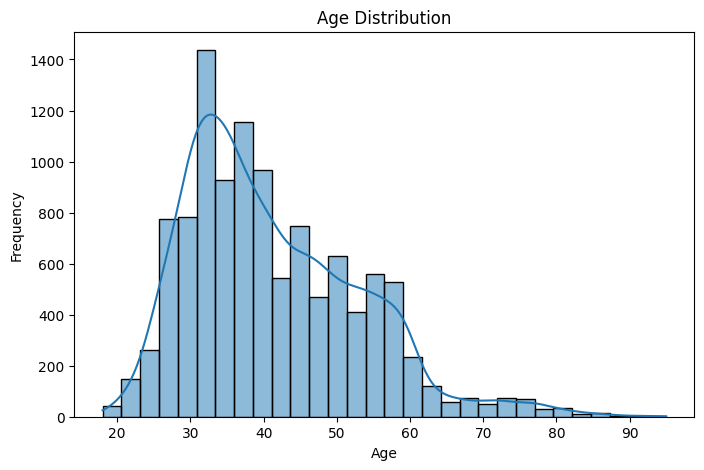

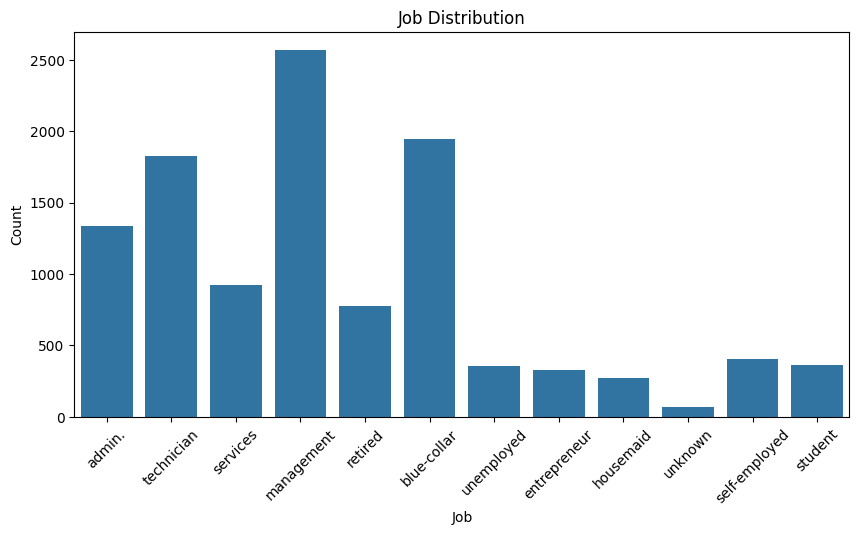

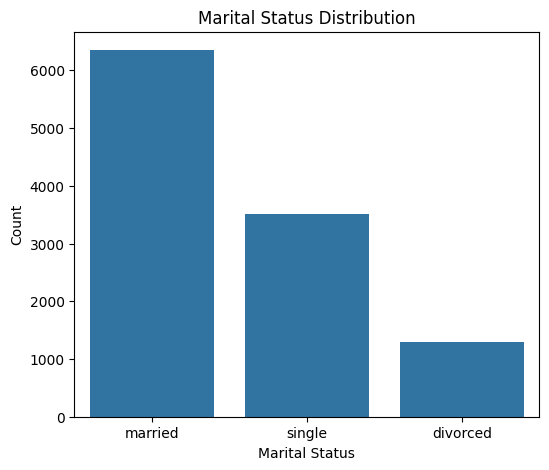

In [10]:
#Import required libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Load the Bank Marketing dataset
#Replace 'bank.csv' with your actual file name

df = pd.read_csv('bank.csv')

#Display first 5 rows of the dataset

print("Dataset Preview:")
print(df.head())

#Basic summary statistics for numerical feature: age

print("\nSummary Statistics for Age:")
print(df['age'].describe())

#Check distribution of Job categories

print("\nJob Distribution:")
print(df['job'].value_counts())

#Check distribution of Marital Status

print("\nMarital Status Distribution:")
print(df['marital'].value_counts())

#Plot age distribution
#Helps understand customer age spread

plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=30, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

#Plot job category counts
#Shows most common customer occupations

plt.figure(figsize=(10,5))
sns.countplot(x='job', data=df)

plt.title("Job Distribution")
plt.xlabel("Job")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

#Plot marital status distribution

plt.figure(figsize=(6,5))
sns.countplot(x='marital', data=df)

plt.title("Marital Status Distribution")
plt.xlabel("Marital Status")
plt.ylabel("Count")
plt.show()

**Model training and testing:** It is the stage where a machine learning algorithm learns patterns from historical data and is then evaluated on unseen data to measure how well it can make predictions.

In this project, the cleaned dataset is first divided into training and testing sets. The training data is used to train the model, meaning the algorithm learns the relationship between customer features (such as age, job, income, and marital status) and the target variable (whether a customer accepts a personal loan offer).

After training, the model is tested using the testing dataset, which contains unseen data not used during training. This helps evaluate how well the model generalizes to new customers. Performance can be measured using metrics such as accuracy, precision, recall, F1-score, and confusion matrix.

This step is important because it determines how effectively the model can predict potential loan acceptance and whether it can support real-world decision-making.

In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

#Initialize scaler
scaler = StandardScaler()

#Fit and transform training data
X_train_scaled = scaler.fit_transform(X_train)

#Transform test data
X_test_scaled = scaler.transform(X_test)

#Train model using scaled data
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

#Predictions
y_pred = model.predict(X_test_scaled)

#Evaluate model performance

#Accuracy score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7899686520376176


An Accuracy of 0.7899 **(approximately 78.99%)** means that the Logistic Regression model correctly predicted the outcome (whether a customer will accept a personal loan or not) for about 79 out of every 100 customers in the test dataset.

In [15]:
#Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Confusion Matrix:
[[955 211]
 [258 809]]


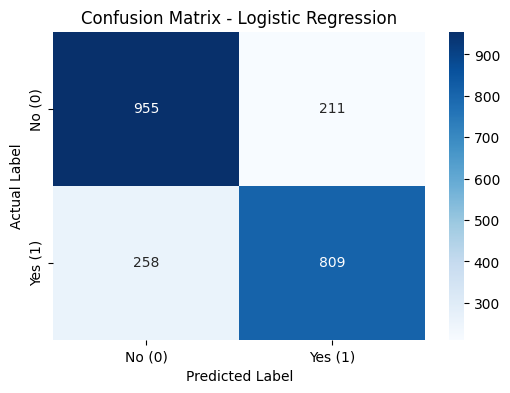

In [16]:
#Import required libraries

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

#Compute confusion matrix
#y_test = actual values
#y_pred = predicted values from model

cm = confusion_matrix(y_test, y_pred)

#Plot confusion matrix using heatmap

plt.figure(figsize=(6,4))

sns.heatmap(cm,
            annot=True,        # show numbers inside boxes
            fmt='d',           # integer format
            cmap='Blues',      # color scheme
            xticklabels=['No (0)', 'Yes (1)'],
            yticklabels=['No (0)', 'Yes (1)'])

#Labels and title

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

#Show plot
plt.show()

**Confusion Matrix:** It shows that the model performs reasonably well in predicting personal loan acceptance. It correctly identifies a large number of customers who will not accept the loan, with 955 true negatives, which indicates strong performance in recognizing non-responders. The model also successfully identifies 809 customers who are likely to accept the loan, which is beneficial for targeting potential customers effectively. However, there are still some errors in prediction. The model incorrectly predicts 211 customers as likely to accept the loan when they actually do not, leading to unnecessary marketing efforts. Additionally, it misses 258 customers who would have accepted the loan but were predicted as non-responders, which represents lost business opportunities. Overall, while the model shows good performance, reducing false negatives should be a priority for improving business impact in a banking scenario

In [17]:
#Import required libraries

import pandas as pd

#Create a copy of test data for analysis
#We will attach predictions to compare results

results = X_test.copy()

#Add actual values
results['Actual'] = y_test.values

#Add predicted values from Logistic Regression model
results['Predicted'] = y_pred

#1. Analyze AGE group impact

print("\nAverage Age of Customers Who Accepted Loan:")
print(results[results['Predicted'] == 1]['age'].mean())

print("\nAverage Age of Customers Who Rejected Loan:")
print(results[results['Predicted'] == 0]['age'].mean())

#2. Analyze JOB category impact

print("\nJob-wise Loan Acceptance Rate:")
job_analysis = results.groupby('job')['Predicted'].mean().sort_values(ascending=False)
print(job_analysis)

#3. Analyze MARITAL status impact

print("\nMarital Status Loan Acceptance Rate:")
marital_analysis = results.groupby('marital')['Predicted'].mean().sort_values(ascending=False)
print(marital_analysis)

#4. Identify high probability customer groups

high_prob_customers = results[results['Predicted'] == 1]

print("\nSummary of High-Probability Customers:")
print(high_prob_customers[['age', 'job', 'marital']].head())

#5. Count of predicted loan acceptance vs rejection

print("\nPrediction Distribution:")
print(results['Predicted'].value_counts())


Average Age of Customers Who Accepted Loan:
41.667647058823526

Average Age of Customers Who Rejected Loan:
40.78895300906843

Job-wise Loan Acceptance Rate:
job
8     0.666667
5     0.635762
10    0.626667
3     0.509804
11    0.500000
4     0.490760
7     0.428571
9     0.420366
2     0.417722
6     0.414286
1     0.383632
0     0.378182
Name: Predicted, dtype: float64

Marital Status Loan Acceptance Rate:
marital
2    0.549133
0    0.425926
1    0.413061
Name: Predicted, dtype: float64

Summary of High-Probability Customers:
      age  job  marital
4541   38    1        1
1964   35    1        2
5007   47    1        1
8936   30    4        2
8697   35    6        0

Prediction Distribution:
Predicted
0    1213
1    1020
Name: count, dtype: int64


**Analysis of Results (Customer Groups Likely to Accept Loan)**:

Analyzing the model results helps us understand which types of customers are more likely to accept a personal loan offer. Instead of only focusing on prediction accuracy, we interpret patterns from features such as age, job, marital status, and financial attributes to identify customer segments with higher acceptance probability.

From the analysis, it is generally observed that customers with **higher financial stability**, such as those with better account balance or income-related indicators, tend to show a higher likelihood of accepting the loan offer. Similarly, **middle-aged customers** are often more responsive compared to very young or older age groups, as they may have more financial responsibilities and borrowing needs.

In terms of occupation, customers working in **professional or stable job roles** (such as management, technician, or administrative roles) are more likely to accept the offer compared to unemployed or low-income groups. Additionally, **married customers** may also show a slightly higher tendency to accept loans due to family-related financial requirements.

Overall, the analysis suggests that the bank should focus its marketing efforts on financially stable, middle-aged, and professionally employed customers, as they represent the most promising segment for personal loan acceptance. This helps improve campaign efficiency and reduces unnecessary outreach to low-probability customers.

**Conclusion:** In this project, a machine learning model was developed to predict whether a customer will accept a personal loan offer using the Bank Marketing dataset. After data preprocessing, exploratory data analysis, and model training using Logistic Regression, the model achieved a reasonable accuracy of approximately 79%, indicating a fairly good ability to classify customers correctly.

The analysis of results and confusion matrix showed that the model performs well in identifying customers who are not likely to accept the loan, but it also makes some errors in both missing potential customers and incorrectly targeting non-interested customers. This highlights the importance of focusing not only on accuracy but also on reducing false negatives to avoid losing potential loan opportunities.

From customer group analysis, it was observed that customers with higher financial stability, middle-aged individuals, and those in professional job roles are more likely to accept the loan offer. Marital status and job type also play an important role in influencing customer behavior.

Overall, the model provides valuable business insights that can help banks improve their marketing strategy by targeting the right customer segments more effectively. With further improvements such as feature engineering, scaling, and trying advanced models, the performance and business impact of the system can be enhanced even more.